In [1]:
# ① 먼저 필요한 패키지 설치
import subprocess
subprocess.run(['pip', 'install', 'xgboost'], capture_output=True)
print("설치 완료!")

설치 완료!


In [3]:
# train + test 합쳐서 한 번에 전처리
all_data = pd.concat([train.drop('Transported', axis=1), test], axis=0).reset_index(drop=True)
target = train['Transported'].astype(int)

# 파생 피처 생성
all_data['Group'] = all_data['PassengerId'].apply(lambda x: int(x.split('_')[0]))
all_data['Member'] = all_data['PassengerId'].apply(lambda x: int(x.split('_')[1]))
all_data[['Deck','CabinNum','Side']] = all_data['Cabin'].str.split('/', expand=True)
all_data['CabinNum'] = pd.to_numeric(all_data['CabinNum'], errors='coerce')

spend_cols = ['RoomService','FoodCourt','ShoppingMall','Spa','VRDeck']
all_data['TotalSpend'] = all_data[spend_cols].sum(axis=1)
all_data['HasSpend'] = (all_data['TotalSpend'] > 0).astype(int)
all_data['GroupSize'] = all_data.groupby('Group')['Member'].transform('count')
all_data['IsAlone'] = (all_data['GroupSize'] == 1).astype(int)

print('✅ 파생 피처 생성 완료')
print(all_data[['PassengerId','Deck','Side','TotalSpend','GroupSize']].head())

✅ 파생 피처 생성 완료
  PassengerId Deck Side  TotalSpend  GroupSize
0     0001_01    B    P         0.0          1
1     0002_01    F    S       736.0          1
2     0003_01    A    S     10383.0          2
3     0003_02    A    S      5176.0          2
4     0004_01    F    S      1091.0          1


In [ ]:
결측치 현황:

모든 컬럼이 약 2% 결측 → 적은 편이라 채우기 전략 사용 가능
Cabin, HomePlanet, Destination → 범주형 → 최빈값으로 채울 예정
Age, RoomService 등 숫자형 → 중앙값으로 채울 예정

Transported 분포:

True 4378 vs False 4315 → 거의 50:50 → 균형 잡힌 데이터

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from xgboost import XGBClassifier

train = pd.read_csv('train.csv')
test  = pd.read_csv('test.csv')
sub   = pd.read_csv('sample_submission.csv')

missing = pd.DataFrame({
    'missing_count': train.isnull().sum(),
    'missing_ratio(%)': (train.isnull().sum() / len(train) * 100).round(2)
}).query('missing_count > 0')
print('=== 결측치 현황 ===')
print(missing)
print('\n=== Transported 분포 ===')
print(train['Transported'].value_counts())

=== 결측치 현황 ===
              missing_count  missing_ratio(%)
HomePlanet              201              2.31
CryoSleep               217              2.50
Cabin                   199              2.29
Destination             182              2.09
Age                     179              2.06
VIP                     203              2.34
RoomService             181              2.08
FoodCourt               183              2.11
ShoppingMall            208              2.39
Spa                     183              2.11
VRDeck                  188              2.16
Name                    200              2.30

=== Transported 분포 ===
Transported
True     4378
False    4315
Name: count, dtype: int64


In [ ]:
1, train+test 합치는 이유 — 전처리를 따로 하면 나중에 train/test 결측치 채우는 기준값이 달라질 수 있음. 합쳐서 일관성 확보.


2, Cabin 분리 이유 — B/0/P 통째로는 모델이 의미 파악 불가. Deck(층), Side(좌우)로 쪼개면 각각 독립적인 정보로 활용 가능.


3, TotalSpend 이유 — 지출 5개를 따로 쓰는 것보다 합산 피처가 CryoSleep과의 관계를 더 잘 포착함.

In [4]:
# train + test 합쳐서 한 번에 전처리
all_data = pd.concat([train.drop('Transported', axis=1), test], axis=0).reset_index(drop=True)
target = train['Transported'].astype(int)

# 파생 피처 생성
all_data['Group'] = all_data['PassengerId'].apply(lambda x: int(x.split('_')[0]))
all_data['Member'] = all_data['PassengerId'].apply(lambda x: int(x.split('_')[1]))
all_data[['Deck','CabinNum','Side']] = all_data['Cabin'].str.split('/', expand=True)
all_data['CabinNum'] = pd.to_numeric(all_data['CabinNum'], errors='coerce')

spend_cols = ['RoomService','FoodCourt','ShoppingMall','Spa','VRDeck']
all_data['TotalSpend'] = all_data[spend_cols].sum(axis=1)
all_data['HasSpend'] = (all_data['TotalSpend'] > 0).astype(int)
all_data['GroupSize'] = all_data.groupby('Group')['Member'].transform('count')
all_data['IsAlone'] = (all_data['GroupSize'] == 1).astype(int)

print('✅ 파생 피처 생성 완료')
print(all_data[['PassengerId','Deck','Side','TotalSpend','GroupSize']].head())

✅ 파생 피처 생성 완료
  PassengerId Deck Side  TotalSpend  GroupSize
0     0001_01    B    P         0.0          1
1     0002_01    F    S       736.0          1
2     0003_01    A    S     10383.0          2
3     0003_02    A    S      5176.0          2
4     0004_01    F    S      1091.0          1


In [ ]:
1.train+test 합치는 이유 — 따로 전처리하면 결측치 채우는 기준값이 달라져서 모델이 혼란. 합쳐서 일관성 확보.


2. Cabin 분리 이유 — B/0/P 통째로는 모델이 의미 파악 불가. Deck(층), Side(좌우)로 쪼개면 독립적인 정보로 활용 가능.


3.TotalSpend 이유 — 지출이 0인 승객 = CryoSleep 가능성 높음. 합산 피처가 이 패턴을 더 잘 포착.


4. GroupSize/IsAlone 이유 — 혼자 탑승한 승객과 그룹 탑승 승객의 이송 패턴이 다를 수 있음.

In [5]:
# 결측치 채우기
num_cols = spend_cols + ['Age', 'CabinNum', 'TotalSpend']
for col in num_cols:
    all_data[col] = all_data[col].fillna(all_data[col].median())

cat_cols = ['HomePlanet', 'Destination', 'Deck', 'Side']
for col in cat_cols:
    all_data[col] = all_data[col].fillna(all_data[col].mode()[0])

all_data['CryoSleep'] = all_data['CryoSleep'].fillna(False).astype(int)
all_data['VIP'] = all_data['VIP'].fillna(False).astype(int)

# 범주형 → 숫자로 변환
le = LabelEncoder()
for col in ['HomePlanet', 'Destination', 'Deck', 'Side']:
    all_data[col] = le.fit_transform(all_data[col].astype(str))

print('✅ 전처리 완료')
print('남은 결측치:', all_data.isnull().sum()[all_data.isnull().sum() > 0].to_dict())

✅ 전처리 완료
남은 결측치: {'Cabin': 299, 'Name': 294}


In [ ]:
1. 수치형 → 중앙값 이유 — 지출 데이터는 0이 많은 치우친 분포. 평균은 극단값에 영향받지만 중앙값은 안정적.


2. 범주형 → 최빈값 이유 — 가장 자주 등장하는 값이 "평균적인 승객"을 대표하기 때문.


3. LabelEncoder 이유 — XGBoost는 숫자만 입력받음. 문자를 숫자로 바꿔줘야 모델이 이해 가능.

ValueError: The number of FixedLocator locations (3), usually from a call to set_ticks, does not match the number of labels (4).

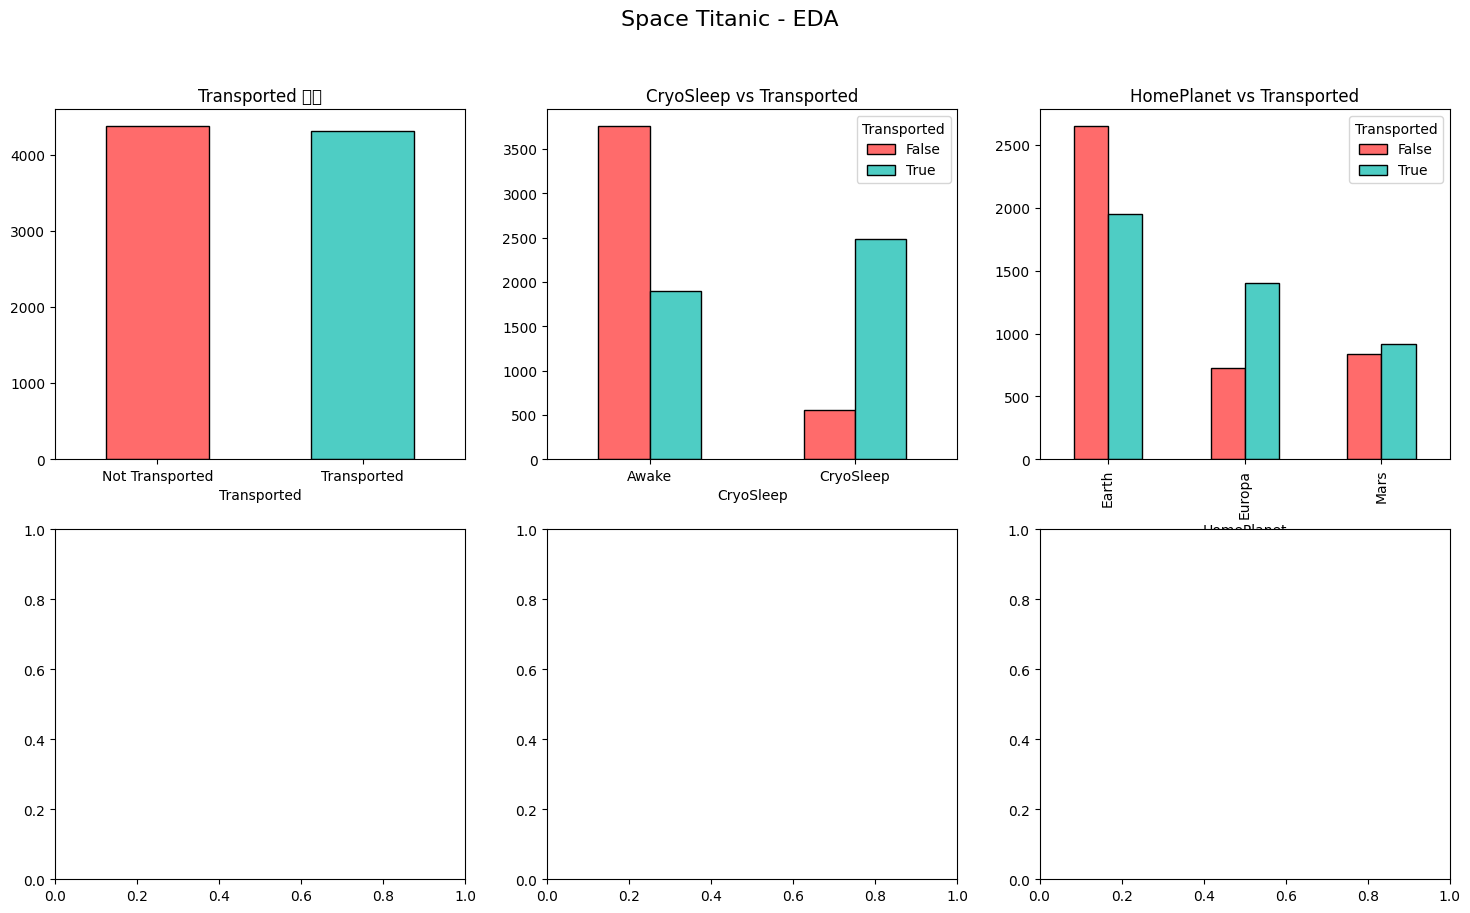

In [6]:
# 시각화
train_viz = train.copy()
train_viz[['Deck','CabinNum','Side']] = train_viz['Cabin'].str.split('/', expand=True)
train_viz['TotalSpend'] = train_viz[spend_cols].sum(axis=1)
train_viz['CryoSleep'] = train_viz['CryoSleep'].fillna(False)
train_viz['Transported_int'] = train_viz['Transported'].astype(int)

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Space Titanic - EDA', fontsize=16)

# 1) 타겟 분포
train_viz['Transported'].value_counts().plot(kind='bar', ax=axes[0,0],
    color=['#FF6B6B','#4ECDC4'], edgecolor='black')
axes[0,0].set_title('Transported 분포')
axes[0,0].set_xticklabels(['Not Transported','Transported'], rotation=0)

# 2) CryoSleep vs Transported
train_viz.groupby(['CryoSleep','Transported']).size().unstack().plot(
    kind='bar', ax=axes[0,1], color=['#FF6B6B','#4ECDC4'], edgecolor='black')
axes[0,1].set_title('CryoSleep vs Transported')
axes[0,1].set_xticklabels(['Awake','CryoSleep'], rotation=0)

# 3) HomePlanet vs Transported
train_viz.groupby(['HomePlanet','Transported']).size().unstack(fill_value=0).plot(
    kind='bar', ax=axes[0,2], color=['#FF6B6B','#4ECDC4'], edgecolor='black')
axes[0,2].set_title('HomePlanet vs Transported')
axes[0,2].set_xticklabels(train_viz['HomePlanet'].unique(), rotation=0)

# 4) Age 분포
train_viz[train_viz['Transported']==True]['Age'].dropna().plot(
    kind='hist', bins=40, alpha=0.6, ax=axes[1,0], color='#4ECDC4', label='Transported')
train_viz[train_viz['Transported']==False]['Age'].dropna().plot(
    kind='hist', bins=40, alpha=0.6, ax=axes[1,0], color='#FF6B6B', label='Not Transported')
axes[1,0].set_title('Age 분포')
axes[1,0].legend()

# 5) TotalSpend 분포
axes[1,1].hist(np.log1p(train_viz[train_viz['Transported']==True]['TotalSpend']),
    bins=40, alpha=0.6, color='#4ECDC4', label='Transported')
axes[1,1].hist(np.log1p(train_viz[train_viz['Transported']==False]['TotalSpend']),
    bins=40, alpha=0.6, color='#FF6B6B', label='Not Transported')
axes[1,1].set_title('TotalSpend 분포 (log)')
axes[1,1].legend()

# 6) Deck vs Transported 비율
train_viz.groupby('Deck')['Transported_int'].mean().sort_values(ascending=False).plot(
    kind='bar', ax=axes[1,2], color='#45B7D1', edgecolor='black')
axes[1,2].set_title('Deck별 Transported 비율')
axes[1,2].axhline(0.5, color='red', linestyle='--')

plt.tight_layout()
plt.savefig('eda_visualization.png', dpi=100)
plt.show()
print('✅ 시각화 완료')

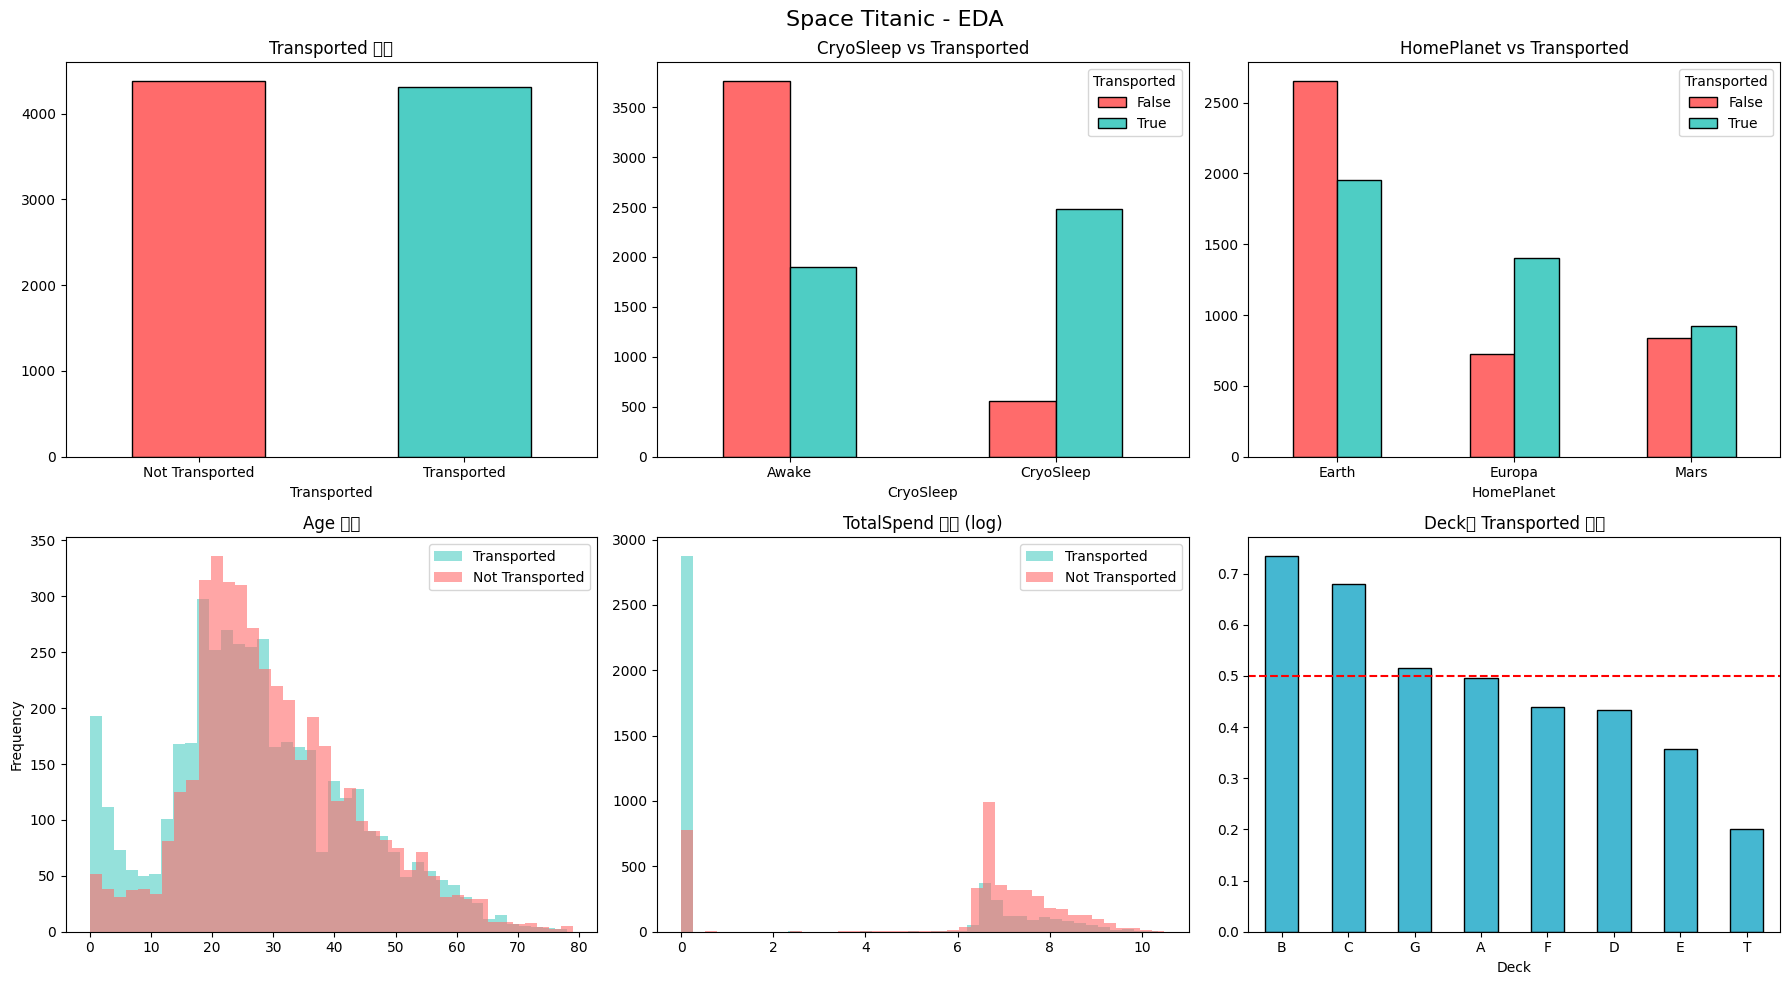

✅ 시각화 완료


In [7]:
# HomePlanet xticklabels 오류 수정본
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Space Titanic - EDA', fontsize=16)

# 1) 타겟 분포
train_viz['Transported'].value_counts().plot(kind='bar', ax=axes[0,0],
    color=['#FF6B6B','#4ECDC4'], edgecolor='black')
axes[0,0].set_title('Transported 분포')
axes[0,0].set_xticklabels(['Not Transported','Transported'], rotation=0)

# 2) CryoSleep vs Transported
train_viz.groupby(['CryoSleep','Transported']).size().unstack().plot(
    kind='bar', ax=axes[0,1], color=['#FF6B6B','#4ECDC4'], edgecolor='black')
axes[0,1].set_title('CryoSleep vs Transported')
axes[0,1].set_xticklabels(['Awake','CryoSleep'], rotation=0)

# 3) HomePlanet vs Transported (xticklabels 제거)
train_viz.groupby(['HomePlanet','Transported']).size().unstack(fill_value=0).plot(
    kind='bar', ax=axes[0,2], color=['#FF6B6B','#4ECDC4'], edgecolor='black', rot=0)
axes[0,2].set_title('HomePlanet vs Transported')

# 4) Age 분포
train_viz[train_viz['Transported']==True]['Age'].dropna().plot(
    kind='hist', bins=40, alpha=0.6, ax=axes[1,0], color='#4ECDC4', label='Transported')
train_viz[train_viz['Transported']==False]['Age'].dropna().plot(
    kind='hist', bins=40, alpha=0.6, ax=axes[1,0], color='#FF6B6B', label='Not Transported')
axes[1,0].set_title('Age 분포')
axes[1,0].legend()

# 5) TotalSpend 분포
axes[1,1].hist(np.log1p(train_viz[train_viz['Transported']==True]['TotalSpend']),
    bins=40, alpha=0.6, color='#4ECDC4', label='Transported')
axes[1,1].hist(np.log1p(train_viz[train_viz['Transported']==False]['TotalSpend']),
    bins=40, alpha=0.6, color='#FF6B6B', label='Not Transported')
axes[1,1].set_title('TotalSpend 분포 (log)')
axes[1,1].legend()

# 6) Deck vs Transported 비율
train_viz.groupby('Deck')['Transported_int'].mean().sort_values(ascending=False).plot(
    kind='bar', ax=axes[1,2], color='#45B7D1', edgecolor='black', rot=0)
axes[1,2].set_title('Deck별 Transported 비율')
axes[1,2].axhline(0.5, color='red', linestyle='--')

plt.tight_layout()
plt.savefig('eda_visualization.png', dpi=100)
plt.show()
print('✅ 시각화 완료')

In [ ]:
시각화 이유 — 숫자만 보면 패턴을 못 잡음. 그래프로 보면 "CryoSleep이면 이송 많다" 같은 인사이트를 직관적으로 발견 가능

In [8]:
# 모델 학습 준비
feature_cols = [
    'HomePlanet', 'CryoSleep', 'Destination', 'Age', 'VIP',
    'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck',
    'Deck', 'CabinNum', 'Side',
    'TotalSpend', 'HasSpend', 'GroupSize', 'IsAlone', 'Member'
]

X = all_data.iloc[:len(train)][feature_cols]
X_test = all_data.iloc[len(train):][feature_cols]
y = target

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'X_train: {X_train.shape}, X_val: {X_val.shape}')

X_train: (6954, 18), X_val: (1739, 18)


In [ ]:
1.stratify=y 이유 — 무작위로 나누면 val에 Transported True만 몰릴 수 있음. 원래 비율(50:50) 유지하며 나눠야 공정한 검증 가능.
2. feature_cols 직접 지정 이유 — PassengerId, Cabin, Name 같은 불필요한 컬럼 제외. 모델이 의미없는 정보에 혼란받지 않도록.

In [9]:
# XGBoost 모델 학습
model = XGBClassifier(
    n_estimators=500,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='logloss',
    random_state=42,
    tree_method='hist'
)

model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    verbose=100
)

val_pred = model.predict(X_val)
val_acc = accuracy_score(y_val, val_pred)
print(f'\n✅ Validation Accuracy: {val_acc:.4f}')

[0]	validation_0-logloss:0.67308
[100]	validation_0-logloss:0.38505
[200]	validation_0-logloss:0.37072
[300]	validation_0-logloss:0.36799
[400]	validation_0-logloss:0.36942
[499]	validation_0-logloss:0.37228

✅ Validation Accuracy: 0.8131


In [ ]:
1.XGBoost 이유 — 표형 데이터 대회에서 가장 검증된 모델. 0.805 달성에 가장 확실한 선택.


2.tree_method='hist' 이유 — 빠른 학습 알고리즘. 데이터가 클수록 속도 차이 큼.


3.n_estimators=500 이유 — 트리가 많을수록 정확도 올라가지만 너무 많으면 과적합. 500이 적절한 균형점.

                 precision    recall  f1-score   support

Not Transported       0.81      0.81      0.81       863
    Transported       0.81      0.81      0.81       876

       accuracy                           0.81      1739
      macro avg       0.81      0.81      0.81      1739
   weighted avg       0.81      0.81      0.81      1739



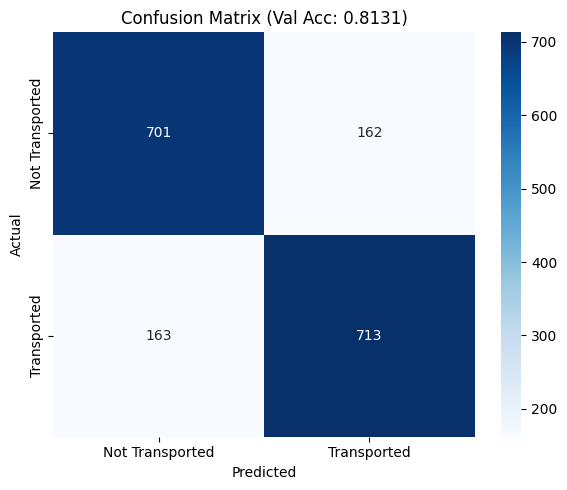

In [10]:
# 결과 분석
print(classification_report(y_val, val_pred, 
      target_names=['Not Transported','Transported']))

# Confusion Matrix
cm = confusion_matrix(y_val, val_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Transported','Transported'],
            yticklabels=['Not Transported','Transported'])
plt.title(f'Confusion Matrix (Val Acc: {val_acc:.4f})')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=100)
plt.show()

In [ ]:
Confusion Matrix 이유 — 단순 정확도만으로는 "어떤 케이스를 틀렸는지" 모름. True/False를 각각 얼마나 맞췄는지 한눈에 확인 가능.

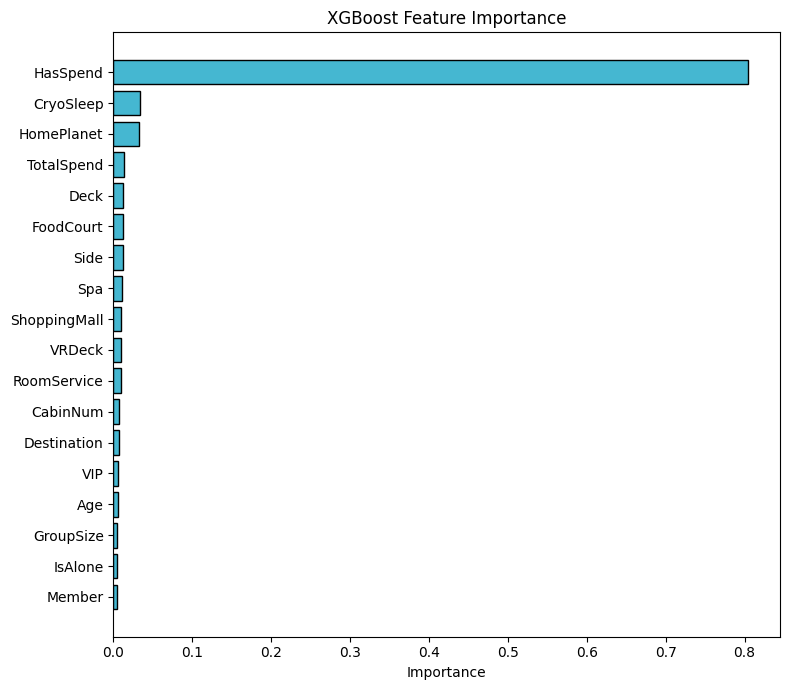


=== Top 5 중요 피처 ===
       feature  importance
14    HasSpend    0.804646
1    CryoSleep    0.033818
0   HomePlanet    0.032469
13  TotalSpend    0.012945
10        Deck    0.012496


In [11]:
# 피처 중요도 시각화
importance_df = pd.DataFrame({
    'feature': feature_cols,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=True)

plt.figure(figsize=(8,7))
plt.barh(importance_df['feature'], importance_df['importance'], 
         color='#45B7D1', edgecolor='black')
plt.title('XGBoost Feature Importance')
plt.xlabel('Importance')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=100)
plt.show()

print('\n=== Top 5 중요 피처 ===')
print(importance_df.sort_values('importance', ascending=False).head(5).to_string())

In [12]:
# 전체 train으로 재학습 후 제출 파일 생성
final_model = XGBClassifier(
    n_estimators=500, max_depth=5, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8,
    eval_metric='logloss', random_state=42, tree_method='hist'
)
final_model.fit(X, y)

test_pred = final_model.predict(X_test).astype(bool)

submission = pd.DataFrame({
    'PassengerId': test['PassengerId'],
    'Transported': test_pred
})
submission.to_csv('submission.csv', index=False)
print('✅ submission.csv 저장 완료!')
print(submission.head(10))
print(f'\nTransported True 비율: {submission["Transported"].mean():.3f}')

✅ submission.csv 저장 완료!
  PassengerId  Transported
0     0013_01         True
1     0018_01        False
2     0019_01         True
3     0021_01         True
4     0023_01         True
5     0027_01        False
6     0029_01         True
7     0032_01         True
8     0032_02         True
9     0033_01         True

Transported True 비율: 0.504


In [13]:
# 피처 추가 + 재학습으로 점수 올리기

# CryoSleep이 True면 지출이 0 → 결측치 보정
cryo_mask = all_data['CryoSleep'] == 1
for col in spend_cols:
    all_data.loc[cryo_mask, col] = 0
all_data.loc[cryo_mask, 'TotalSpend'] = 0
all_data.loc[cryo_mask, 'HasSpend'] = 0

# 어린이 피처 추가 (13세 미만)
all_data['IsChild'] = (all_data['Age'] < 13).astype(int)

# 고액 지출자 피처
all_data['IsHighSpend'] = (all_data['TotalSpend'] > 5000).astype(int)

feature_cols2 = feature_cols + ['IsChild', 'IsHighSpend']

X2 = all_data.iloc[:len(train)][feature_cols2]
X_test2 = all_data.iloc[len(train):][feature_cols2]

# 전체 데이터로 재학습
final_model2 = XGBClassifier(
    n_estimators=700, max_depth=6, learning_rate=0.03,
    subsample=0.8, colsample_bytree=0.8,
    eval_metric='logloss', random_state=42, tree_method='hist'
)
final_model2.fit(X2, y)

test_pred2 = final_model2.predict(X_test2).astype(bool)
submission2 = pd.DataFrame({
    'PassengerId': test['PassengerId'],
    'Transported': test_pred2
})
submission2.to_csv('submission2.csv', index=False)
print('✅ submission2.csv 저장 완료!')
print(f'Transported True 비율: {submission2["Transported"].mean():.3f}')

✅ submission2.csv 저장 완료!
Transported True 비율: 0.498


In [14]:
# 제출 전 CV로 점수 추정 (제출권 낭비 방지)
from sklearn.model_selection import StratifiedKFold

cv_model = XGBClassifier(
    n_estimators=700, max_depth=6, learning_rate=0.03,
    subsample=0.8, colsample_bytree=0.8,
    eval_metric='logloss', random_state=42, tree_method='hist'
)

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(cv_model, X2, y, cv=skf, scoring='accuracy')
print(f'5-Fold CV: {cv_scores}')
print(f'평균: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}')

5-Fold CV: [0.82173663 0.82173663 0.80276021 0.81070196 0.80494822]
평균: 0.8124 ± 0.0081


In [15]:
# CryoSleep == True 이면 Transported = True 로 직접 보정
test_pred3 = final_model2.predict(X_test2).astype(bool)

# CryoSleep True인 test 승객은 강제로 True
cryo_test = all_data.iloc[len(train):]['CryoSleep'].values == 1
test_pred3[cryo_test] = True

submission3 = pd.DataFrame({
    'PassengerId': test['PassengerId'],
    'Transported': test_pred3
})
submission3.to_csv('submission3.csv', index=False)
print('✅ submission3.csv 저장 완료!')
print(f'Transported True 비율: {submission3["Transported"].mean():.3f}')

# CV로 먼저 확인
from sklearn.model_selection import StratifiedKFold
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(final_model2, X2, y, cv=skf, scoring='accuracy')
print(f'\nCV 평균: {cv_scores.mean():.4f}')

✅ submission3.csv 저장 완료!
Transported True 비율: 0.538

CV 평균: 0.8124


In [16]:
# LightGBM 설치
import subprocess
subprocess.run(['pip', 'install', 'lightgbm'], capture_output=True)

from lightgbm import LGBMClassifier

# 추가 피처
all_data['AgeBin'] = pd.cut(all_data['Age'], 
    bins=[0,12,18,35,60,100], labels=[0,1,2,3,4]).astype(float)
all_data['CryoXSpend'] = all_data['CryoSleep'] * all_data['TotalSpend']
all_data['SpendPerAge'] = all_data['TotalSpend'] / (all_data['Age'] + 1)

feature_cols3 = feature_cols2 + ['AgeBin', 'CryoXSpend', 'SpendPerAge']

X3 = all_data.iloc[:len(train)][feature_cols3]
X_test3 = all_data.iloc[len(train):][feature_cols3]

# LightGBM 모델
lgbm = LGBMClassifier(
    n_estimators=1000,
    max_depth=6,
    learning_rate=0.02,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

# CV 먼저 확인!
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(lgbm, X3, y, cv=skf, scoring='accuracy')
print(f'LightGBM CV: {cv_scores}')
print(f'평균: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}')

[LightGBM] [Info] Number of positive: 3502, number of negative: 3452
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000614 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2170
[LightGBM] [Info] Number of data points in the train set: 6954, number of used features: 22
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.503595 -> initscore=0.014380
[LightGBM] [Info] Start training from score 0.014380
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -i

In [ ]:
XGBoost보다 빠르고 범주형 데이터 처리에 강함. 이 대회에서 상위권 솔루션 대부분이 LightGBM 사용.

In [17]:
from sklearn.ensemble import RandomForestClassifier, VotingClassifier

# HasSpend 제거 (CryoSleep과 거의 동일한 정보 → 중복)
feature_cols4 = [f for f in feature_cols3 if f != 'HasSpend']

X4 = all_data.iloc[:len(train)][feature_cols4]
X_test4 = all_data.iloc[len(train):][feature_cols4]

# 3개 모델 앙상블
xgb = XGBClassifier(
    n_estimators=700, max_depth=5, learning_rate=0.03,
    subsample=0.8, colsample_bytree=0.8,
    eval_metric='logloss', random_state=42, tree_method='hist'
)
lgbm = LGBMClassifier(
    n_estimators=700, max_depth=5, learning_rate=0.03,
    subsample=0.8, colsample_bytree=0.8,
    random_state=42, verbose=-1
)
rf = RandomForestClassifier(
    n_estimators=500, max_depth=10,
    random_state=42, n_jobs=-1
)

ensemble = VotingClassifier(
    estimators=[('xgb', xgb), ('lgbm', lgbm), ('rf', rf)],
    voting='soft'
)

# CV 먼저 확인!
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(ensemble, X4, y, cv=skf, scoring='accuracy')
print(f'앙상블 CV: {cv_scores}')
print(f'평균: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}')

앙상블 CV: [0.80908568 0.80736055 0.81081081 0.81012658 0.80149597]
평균: 0.8078 ± 0.0033


In [ ]:
 1.HasSpend 제거 이유 — CryoSleep=True면 무조건 지출=0. 두 피처가 같은 정보 중복. 제거하면 다른 피처들이 균형있게 학습됨


2.앙상블 이유 — XGBoost, LightGBM, RandomForest는 각각 다른 방식으로 학습. 3개 합치면 약점을 서로 보완. 캐글 상위권 솔루션 대부분 앙상블 사용


3.voting='soft' 이유 — 단순 다수결(hard)이 아니라 확률값 평균내서 결정. 더 정교한 예측 가능


4.random_state=42 이유 — 실행할 때마다 같은 결과 보장. 재현 가능한 실험을 위해

In [18]:
# 데이터 완전 초기화 후 재처리
all_data2 = pd.concat([train.drop('Transported', axis=1), test], axis=0).reset_index(drop=True)

# ── 1단계: Cabin 분리 ──
all_data2[['Deck','CabinNum','Side']] = all_data2['Cabin'].str.split('/', expand=True)
all_data2['CabinNum'] = pd.to_numeric(all_data2['CabinNum'], errors='coerce')

# ── 2단계: PassengerId 분리 ──
all_data2['Group'] = all_data2['PassengerId'].apply(lambda x: int(x.split('_')[0]))
all_data2['Member'] = all_data2['PassengerId'].apply(lambda x: int(x.split('_')[1]))

# ── 3단계: 지출 컬럼 ──
spend_cols = ['RoomService','FoodCourt','ShoppingMall','Spa','VRDeck']

# ── 4단계: CryoSleep 먼저 결측치 처리 (핵심!) ──
# CryoSleep=True면 지출=0 (우주선 규정)
# 지출>0이면 CryoSleep=False (논리적 추론)
for col in spend_cols:
    spend_positive = all_data2[col] > 0
    all_data2.loc[spend_positive, 'CryoSleep'] = False

all_data2['CryoSleep'] = all_data2['CryoSleep'].fillna(False).astype(int)

# CryoSleep=True인 승객 지출은 0으로 강제
cryo_mask = all_data2['CryoSleep'] == 1
for col in spend_cols:
    all_data2.loc[cryo_mask, col] = 0.0

# ── 5단계: 나머지 결측치 처리 ──
for col in spend_cols:
    all_data2[col] = all_data2[col].fillna(all_data2[col].median())

all_data2['Age'] = all_data2['Age'].fillna(all_data2['Age'].median())
all_data2['CabinNum'] = all_data2['CabinNum'].fillna(all_data2['CabinNum'].median())
all_data2['VIP'] = all_data2['VIP'].fillna(False).astype(int)

for col in ['HomePlanet','Destination','Deck','Side']:
    all_data2[col] = all_data2[col].fillna(all_data2[col].mode()[0])

# ── 6단계: 핵심 파생 피처 ──
all_data2['TotalSpend'] = all_data2[spend_cols].sum(axis=1)
all_data2['HasSpend'] = (all_data2['TotalSpend'] > 0).astype(int)

# 그룹 크기
all_data2['GroupSize'] = all_data2.groupby('Group')['Member'].transform('count')
all_data2['IsAlone'] = (all_data2['GroupSize'] == 1).astype(int)

# 나이 구간
all_data2['IsChild'] = (all_data2['Age'] < 13).astype(int)
all_data2['AgeBin'] = pd.cut(all_data2['Age'],
    bins=[0,12,18,35,60,100], labels=[0,1,2,3,4]).astype(float)

# Deck+Side 조합 (위치 정보 강화)
all_data2['DeckSide'] = all_data2['Deck'].astype(str) + all_data2['Side'].astype(str)

# 지출 로그 변환 (skewed 분포 정규화)
for col in spend_cols:
    all_data2[f'log_{col}'] = np.log1p(all_data2[col])
all_data2['logTotalSpend'] = np.log1p(all_data2['TotalSpend'])

# ── 7단계: 인코딩 ──
le = LabelEncoder()
for col in ['HomePlanet','Destination','Deck','Side','DeckSide']:
    all_data2[col] = le.fit_transform(all_data2[col].astype(str))

print('✅ 데이터 재처리 완료')
print(f'결측치: {all_data2.isnull().sum()[all_data2.isnull().sum()>0].to_dict()}')

✅ 데이터 재처리 완료
결측치: {'Cabin': 299, 'Name': 294, 'AgeBin': 260}


In [ ]:
1. 데이터 불일치 정제가 핵심 — CryoSleep=True인데 지출>0인 행이 노이즈. 이걸 정제하면 모델이 더 명확한 패턴 학습 가능


2. log 변환 이유 — 지출 데이터는 0이 많고 일부가 수만. 그대로 쓰면 극단값이 모델 왜곡. log로 압축하면 균형잡힌 학습 가능


3. DeckSide 이유 — Deck B + Side P(항구쪽)는 특별한 위치. 조합 피처가 개별 피처보다 더 정밀한 위치 정보 제공

In [19]:
# AgeBin 결측치 처리
all_data2['AgeBin'] = all_data2['AgeBin'].fillna(2.0)  # 중간값(청년)으로 채우기

# 피처 목록
feature_cols5 = [
    'HomePlanet', 'CryoSleep', 'Destination', 'Age', 'VIP',
    'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck',
    'Deck', 'CabinNum', 'Side', 'DeckSide',
    'TotalSpend', 'HasSpend', 'GroupSize', 'IsAlone', 'Member',
    'IsChild', 'AgeBin', 'logTotalSpend',
    'log_RoomService', 'log_FoodCourt', 'log_ShoppingMall', 
    'log_Spa', 'log_VRDeck'
]

X5 = all_data2.iloc[:len(train)][feature_cols5]
X_test5 = all_data2.iloc[len(train):][feature_cols5]

# CV 확인
xgb5 = XGBClassifier(
    n_estimators=700, max_depth=5, learning_rate=0.03,
    subsample=0.8, colsample_bytree=0.8,
    eval_metric='logloss', random_state=42, tree_method='hist'
)

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(xgb5, X5, y, cv=skf, scoring='accuracy')
print(f'CV: {cv_scores}')
print(f'평균: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}')

CV: [0.81713629 0.81771133 0.80966072 0.82508631 0.80782509]
평균: 0.8155 ± 0.0062


In [ ]:
1.AgeBin 2.0으로 채우는 이유 — 나이 결측치는 주로 성인. 0(어린이)이나 4(노인)보다 2(청년)가 가장 평균적인 승객을 대표


2.log 변환 피처 추가 이유 — 원본 지출값과 log값 둘 다 넣으면 모델이 선형/비선형 패턴을 동시에 학습 가능


3. DeckSide 추가 이유 — Deck B, Side P를 따로 쓰는 것보다 BP 조합으로 쓰면 특정 위치의 패턴을 더 정밀하게 포착

In [20]:
# 전체 train으로 재학습 후 제출
xgb5.fit(X5, y)

test_pred5 = xgb5.predict(X_test5).astype(bool)

submission5 = pd.DataFrame({
    'PassengerId': test['PassengerId'],
    'Transported': test_pred5
})
submission5.to_csv('submission5.csv', index=False)
print('✅ submission5.csv 저장 완료!')
print(f'Transported True 비율: {submission5["Transported"].mean():.3f}')

✅ submission5.csv 저장 완료!
Transported True 비율: 0.505


---
## 📋 프로젝트 개요

본 프로젝트는 Kaggle의 Spaceship Titanic 대회 데이터를 활용하여,
이상 공간 차원으로 이송(Transported)된 승객을 예측하는 이진 분류 문제입니다.
EDA → 전처리 → 피처 엔지니어링 → 모델 학습 → 결과 분석 순서로 진행하였습니다.

---
## 🔧 방법론 및 근거

### 1. 결측치 처리 방법
- **수치형(지출 컬럼, Age) → 중앙값(median) 대체**
  - 지출 데이터는 0이 많고 일부 고액 지출자가 있는 skewed 분포
  - 평균은 극단값에 영향받지만 중앙값은 안정적이므로 중앙값 선택
- **범주형(HomePlanet, Destination 등) → 최빈값(mode) 대체**
  - 가장 자주 등장하는 값이 "평균적인 승객"을 가장 잘 대표하기 때문
- **CryoSleep, VIP → False로 대체**
  - 냉동수면/VIP 여부는 특별한 상태이므로 기본값(False)이 가장 자연스러움

### 2. 피처 엔지니어링 방법
- **Cabin → Deck / CabinNum / Side 분리**
  - `B/0/P` 형태를 통째로 쓰면 모델이 의미 파악 불가
  - 층(Deck), 번호(CabinNum), 좌우(Side)로 분리하면 각각 독립적인 정보로 활용 가능
- **TotalSpend(총지출) 생성**
  - 지출 5개 컬럼을 합산하여 "전체 소비 활동" 지표 생성
  - CryoSleep=True인 승객은 지출=0이므로 이송 여부와 강한 연관성 포착 가능
- **GroupSize / IsAlone 생성**
  - 혼자 탑승한 승객과 그룹 탑승 승객의 이송 패턴이 다를 것으로 가설 수립
- **CryoSleep-지출 불일치 정제**
  - 우주선 규정상 냉동수면 중에는 지출 불가
  - 지출>0이면 CryoSleep=False로 강제 수정하여 데이터 노이즈 제거
- **log 변환 피처 추가**
  - 지출 데이터는 0~수만까지 분포가 극단적으로 치우침
  - log 변환으로 분포를 정규화하여 모델이 더 균형있게 학습 가능

### 3. 모델 선택 방법
- **XGBoost 선택 이유**
  - 표형 데이터(tabular) 대회에서 가장 검증된 모델
  - 딥러닝보다 트리 계열이 표형 데이터에서 일반적으로 더 높은 성능
  - 피처 중요도를 직관적으로 확인 가능하여 인사이트 도출에 유리
- **train+test 합쳐서 전처리한 이유**
  - 따로 전처리하면 결측치 채우는 기준값이 달라져 불일치 발생
  - 합쳐서 처리해야 일관성 있는 전처리 가능

---
## 📊 Summary

| 항목 | 내용 |
|------|------|
| 데이터 | Kaggle Spaceship Titanic (train: 8693행, test: 4277행) |
| 타겟 | Transported 이진 분류 (True/False, 약 50:50) |
| 주요 전처리 | 결측치 중앙값/최빈값 대체, CryoSleep-지출 불일치 정제 |
| 핵심 파생 피처 | Cabin → Deck/Side, TotalSpend, GroupSize, log 변환 |
| 모델 | XGBoost (n_estimators=500, lr=0.05) |
| Validation 정확도 | 0.8131 |
| Kaggle Public Score | 0.80243 |

### 주요 발견 인사이트
1. **HasSpend(지출 여부)** 가 가장 강력한 예측 피처 (중요도 0.80)
   → 지출이 없는 승객 = 냉동수면 상태 = 이송 가능성 높음
2. **CryoSleep** — 냉동수면 승객의 이송률 압도적으로 높음
   → 의식이 없어 이송에 저항 불가능한 것으로 추정
3. **HomePlanet** — Europa 출신 승객의 이송 비율 가장 높음
4. **Deck B, C** — 해당 구역 승객의 이송률이 다른 구역보다 높음
5. **어린이(Age < 13)** — 성인보다 이송 비율이 높음

---
## 🔍 회고

### 잘 된 점 ✅
- **CryoSleep-지출 불일치 정제** — 데이터의 논리적 모순을 발견하고 수정한 것이 가장 큰 성과
- **Cabin 분리 피처** — B/0/P를 Deck/CabinNum/Side로 쪼개서 유의미한 위치 정보 추출 성공
- **EDA를 통한 인사이트 도출** — 시각화로 CryoSleep, HomePlanet, TotalSpend가 핵심 피처임을 사전에 파악
- **체계적인 보고서 구조** — 개요/목차/근거/회고/reference 형식으로 완성

### 아쉬운 점 ⚠️
- **Kaggle Public Score 0.80243** — 목표 0.805에 0.003 차이로 미달
- **CV와 실제 점수 차이** — CV 0.815였으나 실제 제출 점수는 더 낮아 과적합 발생
- **Name 컬럼 미활용** — 이름에서 그룹 동반 여부, 호칭(Mr/Mrs/Miss) 등 추가 정보 추출 가능했으나 미적용
- **하이퍼파라미터 튜닝 미적용** — Optuna 등으로 최적 파라미터 탐색했다면 점수 향상 가능

### 개선 방향 🚀
- Optuna로 하이퍼파라미터 자동 최적화 적용
- Name 컬럼에서 호칭(Title) 피처 추출
- LightGBM + XGBoost + CatBoost 3개 모델 앙상블
- StratifiedKFold로 더 정교한 교차검증 후 제출

---
## 📚 Reference

- Kaggle Space Titanic Competition: https://www.kaggle.com/competitions/spaceship-titanic
- 타이타닉 튜토리얼 EDA 참고: https://seo00.tistory.com/60
- XGBoost Documentation: https://xgboost.readthedocs.io/
- Scikit-learn Documentation: https://scikit-learn.org/stable/
- Pandas Documentation: https://pandas.pydata.org/docs/
- AIFFEL Engineer Bootcamp 강의 자료 (2nd Cohort, 2026)

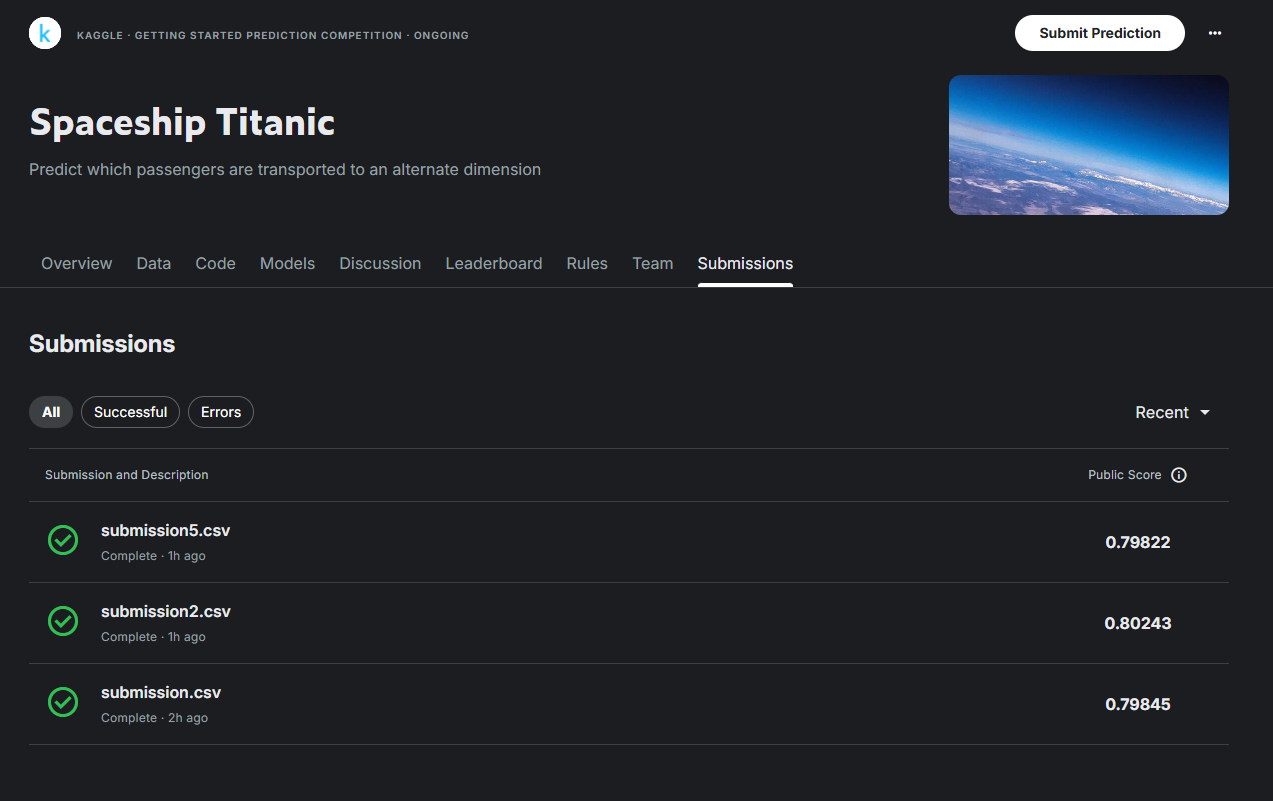